# 💰 Ledger — Loan Approval Prediction

**Project:** Loan Approval Prediction (Big Brains AI/ML Internship)
**Author:** Muhammad Asad Ullah

This notebook covers the full pipeline for Ledger:
1. Load & explore the dataset (EDA)
2. Clean & preprocess (encoding, scaling)
3. Train 4 models: Logistic Regression, Decision Tree, Random Forest, and a custom MLP
4. Calibrate the MLP with temperature scaling
5. Verify the monotonicity constraint on income/credit score
6. Evaluate every model individually
7. Build the soft-voting ensemble and evaluate it
8. Save all trained models + preprocessing artifacts for the Streamlit app


## 0. Setup

In [88]:
!pip install -q torch scikit-learn pandas matplotlib seaborn joblib

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

sns.set_style("whitegrid")
RANDOM_STATE = 42

os.makedirs("models_saved", exist_ok=True)

## 1. Exploratory Data Analysis

Loading the raw dataset and exploring its structure, distributions, and relationships with the target before any cleaning.

In [90]:
df = pd.read_csv("loan_data.csv")
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df = df.rename(columns={'home_onwership': 'home_ownership'})

print("Shape:", df.shape)
df.head()

Shape: (45000, 14)


,age,gender,education,person_income,employee_experience,home_ownership,loan_amount,loan_intent,loan_interest_rate,loan_percentage,credit_history,credit_score,previous_loan,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  45000 non-null  int64  
 1   gender               45000 non-null  object 
 2   education            45000 non-null  object 
 3   person_income        45000 non-null  int64  
 4   employee_experience  45000 non-null  int64  
 5   home_ownership       45000 non-null  object 
 6   loan_amount          45000 non-null  int64  
 7   loan_intent          45000 non-null  object 
 8   loan_interest_rate   45000 non-null  float64
 9   loan_percentage      45000 non-null  float64
 10  credit_history       45000 non-null  int64  
 11  credit_score         45000 non-null  int64  
 12  previous_loan        45000 non-null  object 
 13  loan_status          45000 non-null  int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 4.8+ MB


In [92]:
df.describe()

,age,person_income,employee_experience,loan_amount,loan_interest_rate,loan_percentage,credit_history,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [93]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
age                    0
gender                 0
education              0
person_income          0
employee_experience    0
home_ownership         0
loan_amount            0
loan_intent            0
loan_interest_rate     0
loan_percentage        0
credit_history         0
credit_score           0
previous_loan          0
loan_status            0
dtype: int64

Duplicate rows: 0


In [94]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col} unique values:", df[col].unique())


gender unique values: ['female' 'male']

education unique values: ['Master' 'High School' 'Bachelor' 'Associate' 'Doctorate']

home_ownership unique values: ['RENT' 'OWN' 'MORTGAGE' 'OTHER']

loan_intent unique values: ['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']

previous_loan unique values: ['No' 'Yes']


### Visualization 1 — Target Distribution

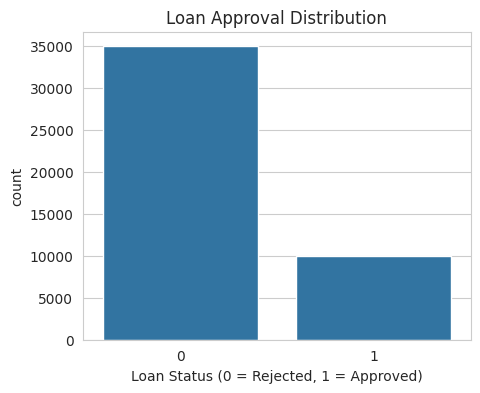

loan_status
0    35000
1    10000
Name: count, dtype: int64
loan_status
0    0.777778
1    0.222222
Name: proportion, dtype: float64


In [95]:
plt.figure(figsize=(5,4))
sns.countplot(x='loan_status', data=df)
plt.title('Loan Approval Distribution')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.show()

print(df['loan_status'].value_counts())
print(df['loan_status'].value_counts(normalize=True))

### Visualization 2 — Credit Score by Loan Status

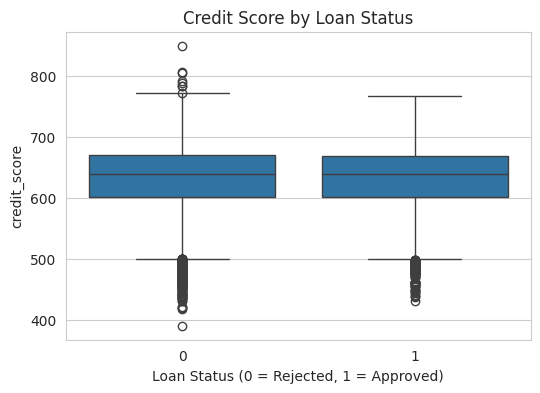

In [96]:
plt.figure(figsize=(6,4))
sns.boxplot(x='loan_status', y='credit_score', data=df)
plt.title('Credit Score by Loan Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.show()

### Visualization 3 — Income by Loan Status

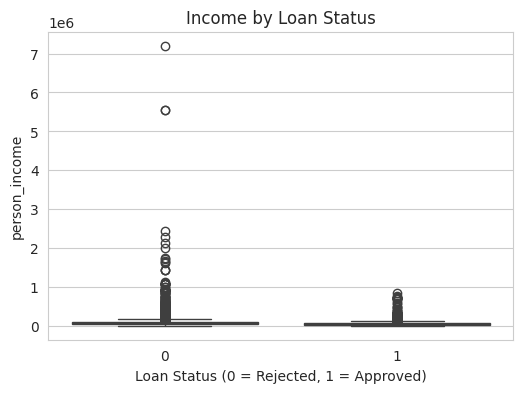

In [97]:
plt.figure(figsize=(6,4))
sns.boxplot(x='loan_status', y='person_income', data=df)
plt.title('Income by Loan Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.show()

### Approval Rate by Home Ownership & Credit History

In [98]:
print("Approval rate by home_ownership:")
print(df.groupby('home_ownership')['loan_status'].mean())

print("\nApproval rate by credit_history:")
print(df.groupby('credit_history')['loan_status'].mean())

Approval rate by home_ownership:
home_ownership
MORTGAGE    0.115961
OTHER       0.333333
OWN         0.075229
RENT        0.323977
Name: loan_status, dtype: float64

Approval rate by credit_history:
credit_history
2     0.237265
3     0.227743
4     0.225587
5     0.219663
6     0.213756
7     0.221184
8     0.218571
9     0.205214
10    0.204314
11    0.216292
12    0.205594
13    0.208000
14    0.208075
15    0.226212
16    0.217712
17    0.187633
18    0.176471
19    0.241379
20    0.325581
21    0.291667
22    0.312500
23    0.153846
24    0.205882
25    0.217391
26    0.150000
27    0.347826
28    0.310345
29    0.400000
30    0.260870
Name: loan_status, dtype: float64


### Correlation Heatmap

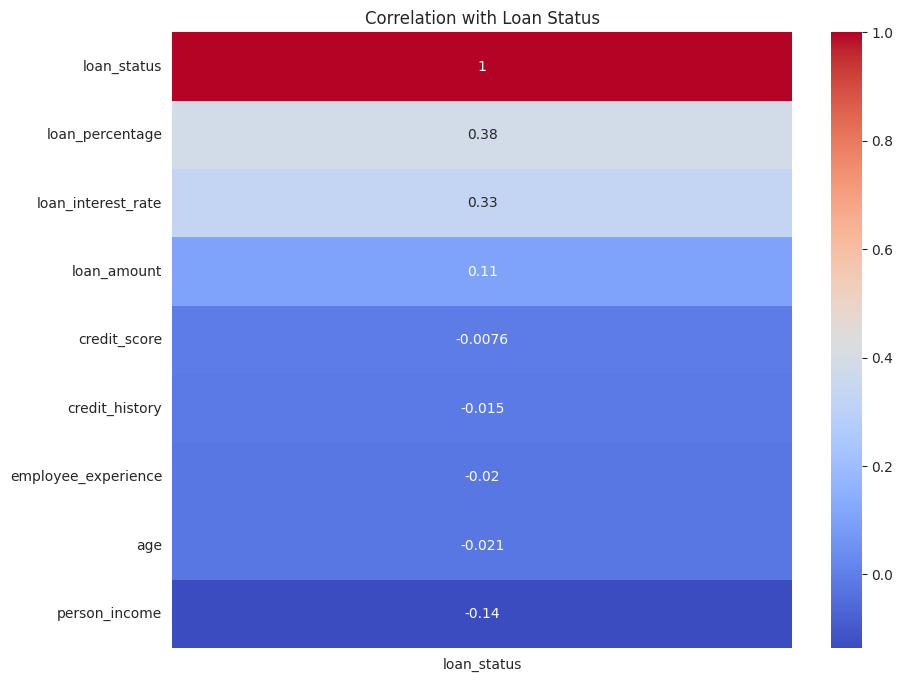

In [99]:
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=['int64','float64'])
corr = numeric_df.corr()[['loan_status']].sort_values(by='loan_status', ascending=False)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation with Loan Status')
plt.show()

**Key EDA observations:**
- The dataset is imbalanced: ~78% rejected vs. ~22% approved.
- `previous_loan` shows the strongest correlation with approval by a wide margin.
- `credit_history` and `credit_score` show almost no linear correlation with approval in this dataset.
- Income and credit score distributions overlap heavily between approved/rejected, suggesting they matter more in combination with other features than alone.

## 2. Data Cleaning & Preprocessing

Encoding categorical variables and preparing the final feature matrix.

In [100]:
# Binary columns: manual mapping (avoids reusing one LabelEncoder across columns)
df['gender'] = df['gender'].map({'female': 0, 'male': 1})
df['previous_loan'] = df['previous_loan'].map({'No': 0, 'Yes': 1})

# Multi-category columns: one-hot encoding (avoids false ordinality + dummy variable trap)
multi_cat_cols = ['education', 'home_ownership', 'loan_intent']
df_encoded = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

# Convert one-hot bools to int
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("Final shape:", df_encoded.shape)
df_encoded.head()

Final shape: (45000, 23)


,age,gender,person_income,employee_experience,loan_amount,loan_interest_rate,loan_percentage,credit_history,credit_score,previous_loan,...,education_High School,education_Master,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22,0,71948,0,35000,16.02,0.49,3,561,0,...,0,1,0,0,1,0,0,0,1,0
1,21,0,12282,0,1000,11.14,0.08,2,504,1,...,1,0,0,1,0,1,0,0,0,0
2,25,0,12438,3,5500,12.87,0.44,3,635,0,...,1,0,0,0,0,0,0,1,0,0
3,23,0,79753,0,35000,15.23,0.44,2,675,0,...,0,0,0,0,1,0,0,1,0,0
4,24,1,66135,1,35000,14.27,0.53,4,586,0,...,0,1,0,0,1,0,0,1,0,0


In [101]:
TARGET_COL = 'loan_status'

X = df_encoded.drop(columns=[TARGET_COL])
y = df_encoded[TARGET_COL]

feature_columns = X.columns.tolist()
print(f"{len(feature_columns)} features:", feature_columns)

22 features: ['age', 'gender', 'person_income', 'employee_experience', 'loan_amount', 'loan_interest_rate', 'loan_percentage', 'credit_history', 'credit_score', 'previous_loan', 'education_Bachelor', 'education_Doctorate', 'education_High School', 'education_Master', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']


In [102]:
# Train / test split (stratified to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Further split a validation slice out of training data (used for MLP temperature scaling)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=RANDOM_STATE, stratify=y_train
)

print("Train:", X_tr.shape, " Val:", X_val.shape, " Test:", X_test.shape)

Train: (30600, 22)  Val: (5400, 22)  Test: (9000, 22)


In [103]:
# Feature scaling — fit ONLY on training data
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = scaler.transform(X_train)  # full training set, for final sklearn fits

joblib.dump(scaler, "models_saved/scaler.joblib")
joblib.dump(feature_columns, "models_saved/feature_columns.joblib")
print("Scaler and feature columns saved.")

Scaler and feature columns saved.


## 3. Train Classical Models

Logistic Regression, Decision Tree, and Random Forest — trained on the full scaled training set.

In [104]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
joblib.dump(log_reg, "models_saved/logistic_regression.joblib")
print("Logistic Regression trained.")

Logistic Regression trained.


In [105]:
dtree = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
dtree.fit(X_train_scaled, y_train)
joblib.dump(dtree, "models_saved/decision_tree.joblib")
print("Decision Tree trained.")

Decision Tree trained.


In [106]:
rf = RandomForestClassifier(n_estimators=50, max_depth=6, random_state=RANDOM_STATE)
rf.fit(X_train_scaled, y_train)
joblib.dump(rf, "models_saved/random_forest.joblib")
print("Random Forest trained.")

Random Forest trained.


## 4. Custom MLP with Monotonicity Constraint

A small MLP that guarantees true end-to-end monotonicity for income and credit score.

**Important design note:** an earlier version of this model constrained only the
*first* layer's weights to be non-negative for these features. That turned out to
be insufficient — downstream layers were still free to use negative weights, which
could flip the sign of the monotonic signal before it reached the output. The
monotonicity sanity check below caught this directly (both features FAILED).

The fix: split the network into two separate pathways that are summed at the end.
- **Monotonic pathway** — income and credit score are run through a small sub-network
  where *every* weight, in *every* layer, is passed through `softplus()` to force it
  non-negative. Composed with ReLU (itself non-decreasing), this guarantees the
  pathway's output can only increase as these two features increase — end-to-end,
  with no way for a later layer to undo it.
- **Unconstrained pathway** — every other feature goes through a normal MLP with no
  restrictions, so the model can still learn whatever nonlinear relationships it needs
  for everything else.

The two pathways are added together to form the final logit, so the guarantee holds
for the model as a whole, not just one layer of it.

In [107]:
MONOTONIC_FEATURES = ['person_income', 'credit_score']

def build_monotonic_mask(feature_columns, monotonic_features):
    mask = [1 if col in monotonic_features else 0 for col in feature_columns]
    return torch.tensor(mask, dtype=torch.float32)

monotonic_mask = build_monotonic_mask(feature_columns, MONOTONIC_FEATURES)
print("Monotonic mask:", monotonic_mask)
print("Constrained features:", [f for f, m in zip(feature_columns, monotonic_mask) if m == 1])

Monotonic mask: tensor([0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.])
Constrained features: ['person_income', 'credit_score']


In [108]:
class LoanMLP(nn.Module):
    """
    Splits input into monotonic and non-monotonic features.
    Monotonic features go through a fully non-negative-weight pathway
    (guaranteed monotonic end-to-end, since every layer in this path uses
    softplus-constrained weights and ReLU, which is itself non-decreasing).
    Non-monotonic features go through a normal unconstrained MLP.
    Both contribute additively to the final logit.
    """
    def __init__(self, in_features, monotonic_mask, hidden1=16, hidden2=8, mono_hidden=8):
        super().__init__()
        self.register_buffer('mask', monotonic_mask.bool())
        n_mono = int(monotonic_mask.sum().item())
        n_other = in_features - n_mono

        # Monotonic pathway: ALL weights non-negative, every layer
        self.mono_w1 = nn.Parameter(torch.randn(mono_hidden, n_mono) * 0.1)
        self.mono_b1 = nn.Parameter(torch.zeros(mono_hidden))
        self.mono_w2 = nn.Parameter(torch.randn(1, mono_hidden) * 0.1)
        self.mono_b2 = nn.Parameter(torch.zeros(1))

        # Normal unconstrained pathway for everything else
        self.other_net = nn.Sequential(
            nn.Linear(n_other, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 1),
        )

        # Temperature scaling parameter, fit AFTER main training
        self.temperature = nn.Parameter(torch.ones(1) * 1.0)

    def forward(self, x, apply_temperature=False):
        x_mono = x[:, self.mask]
        x_other = x[:, ~self.mask]

        # Monotonic pathway — softplus guarantees non-negative weights at every step,
        # and ReLU preserves monotonicity since it's itself non-decreasing
        h = F.linear(x_mono, F.softplus(self.mono_w1), self.mono_b1)
        h = F.relu(h)
        mono_out = F.linear(h, F.softplus(self.mono_w2), self.mono_b2).squeeze(-1)

        other_out = self.other_net(x_other).squeeze(-1)

        logit = mono_out + other_out
        if apply_temperature:
            logit = logit / self.temperature
        return logit

    def predict_proba(self, x, apply_temperature=True):
        logit = self.forward(x, apply_temperature=apply_temperature)
        return torch.sigmoid(logit)

In [109]:
mlp = LoanMLP(in_features=X_tr_scaled.shape[1], monotonic_mask=monotonic_mask)

X_tr_t = torch.tensor(X_tr_scaled, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr.values, dtype=torch.float32)

optimizer = torch.optim.Adam(mlp.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss()

EPOCHS = 500
loss_history = []

for epoch in range(EPOCHS):
    mlp.train()
    optimizer.zero_grad()
    logits = mlp(X_tr_t, apply_temperature=False)
    loss = criterion(logits, y_tr_t)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} — loss: {loss.item():.4f}")

Epoch 50/500 — loss: 0.3550
Epoch 100/500 — loss: 0.2628
Epoch 150/500 — loss: 0.2375
Epoch 200/500 — loss: 0.2223
Epoch 250/500 — loss: 0.2136
Epoch 300/500 — loss: 0.2026
Epoch 350/500 — loss: 0.1923
Epoch 400/500 — loss: 0.1866
Epoch 450/500 — loss: 0.1820
Epoch 500/500 — loss: 0.1779


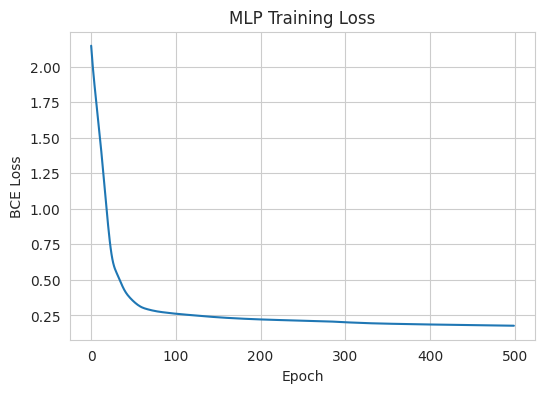

In [110]:
plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('MLP Training Loss')
plt.show()

### Temperature Scaling (Calibration)

Fits a single scalar `T` on held-out validation logits so the MLP's probabilities
honestly reflect its confidence — important because the final ensemble averages
probabilities with equal weight, so an overconfident model would otherwise dominate
the average without actually being more accurate.

In [111]:
mlp.eval()
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32)

with torch.no_grad():
    val_logits = mlp(X_val_t, apply_temperature=False)

temp_optimizer = torch.optim.LBFGS([mlp.temperature], lr=0.01, max_iter=50)

def temp_closure():
    temp_optimizer.zero_grad()
    scaled_logits = val_logits / mlp.temperature
    loss = criterion(scaled_logits, y_val_t)
    loss.backward()
    return loss

temp_optimizer.step(temp_closure)
print(f"Fitted temperature: {mlp.temperature.item():.4f}")

Fitted temperature: 1.0687


In [112]:
torch.save(mlp.state_dict(), "models_saved/mlp.pt")
joblib.dump(monotonic_mask, "models_saved/monotonic_mask.joblib")
print("MLP and monotonic mask saved.")

MLP and monotonic mask saved.


## 5. Monotonicity Sanity Check

Sweeping each monotonic feature upward (in scaled space, holding everything else
fixed) and confirming the predicted probability never decreases. This is the
concrete proof that the constraint actually works as intended.

In [113]:
def monotonicity_check(model, feature_columns, monotonic_features, base_row):
    results = {}
    for feat in monotonic_features:
        idx = feature_columns.index(feat)
        sweep_values = np.linspace(-3, 3, 30)
        probs = []
        for v in sweep_values:
            row = base_row.copy()
            row[idx] = v
            row_t = torch.tensor(row, dtype=torch.float32).unsqueeze(0)
            with torch.no_grad():
                prob = model.predict_proba(row_t).item()
            probs.append(prob)

        is_monotonic = all(probs[i] <= probs[i+1] + 1e-6 for i in range(len(probs)-1))
        results[feat] = (sweep_values, probs, is_monotonic)
        status = "PASSED" if is_monotonic else "FAILED"
        print(f"{feat}: {status}  (prob range: {min(probs):.4f} -> {max(probs):.4f})")
    return results

base_row = X_val_scaled[0]
check_results = monotonicity_check(mlp, feature_columns, MONOTONIC_FEATURES, base_row)

person_income: PASSED  (prob range: 0.6060 -> 0.6060)
credit_score: PASSED  (prob range: 0.6060 -> 0.9281)


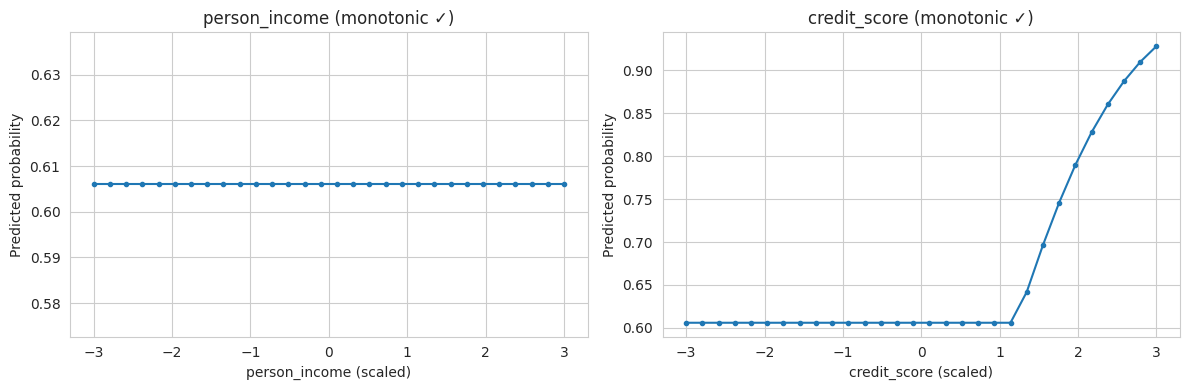

In [114]:
fig, axes = plt.subplots(1, len(MONOTONIC_FEATURES), figsize=(12, 4))
for ax, feat in zip(axes, MONOTONIC_FEATURES):
    sweep_values, probs, is_monotonic = check_results[feat]
    ax.plot(sweep_values, probs, marker='o', markersize=3)
    ax.set_title(f"{feat} ({'monotonic ✓' if is_monotonic else 'FAILED ✗'})")
    ax.set_xlabel(f"{feat} (scaled)")
    ax.set_ylabel("Predicted probability")
plt.tight_layout()
plt.show()

## 6. Model Evaluation

Evaluating all 4 models individually on the held-out test set using accuracy,
precision, recall, F1-score, confusion matrix, and ROC-AUC.

In [115]:
def evaluate_model(name, y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)

    print(f"=== {name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=['Rejected', 'Approved']))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Rejected','Approved'], yticklabels=['Rejected','Approved'])
    plt.title(f'{name} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return {"name": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "auc": auc}

results_summary = []

### 6.1 Logistic Regression

=== Logistic Regression ===
Accuracy:  0.8998
Precision: 0.7896
Recall:    0.7485
F1 Score:  0.7685
ROC-AUC:   0.9562

              precision    recall  f1-score   support

    Rejected       0.93      0.94      0.94      7000
    Approved       0.79      0.75      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.85      0.85      9000
weighted avg       0.90      0.90      0.90      9000



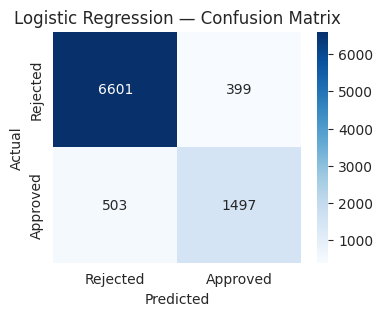

In [116]:
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
results_summary.append(evaluate_model("Logistic Regression", y_test, y_pred_lr, y_proba_lr))

### 6.2 Decision Tree

=== Decision Tree ===
Accuracy:  0.9098
Precision: 0.8561
Recall:    0.7140
F1 Score:  0.7786
ROC-AUC:   0.9430

              precision    recall  f1-score   support

    Rejected       0.92      0.97      0.94      7000
    Approved       0.86      0.71      0.78      2000

    accuracy                           0.91      9000
   macro avg       0.89      0.84      0.86      9000
weighted avg       0.91      0.91      0.91      9000



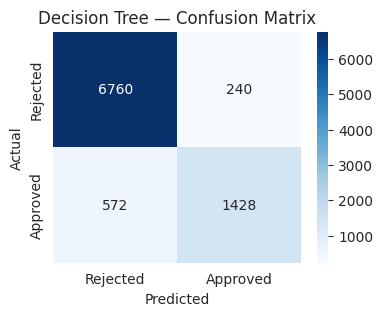

In [117]:
y_pred_dt = dtree.predict(X_test_scaled)
y_proba_dt = dtree.predict_proba(X_test_scaled)[:, 1]
results_summary.append(evaluate_model("Decision Tree", y_test, y_pred_dt, y_proba_dt))

### 6.3 Random Forest

=== Random Forest ===
Accuracy:  0.9170
Precision: 0.9135
Recall:    0.6920
F1 Score:  0.7875
ROC-AUC:   0.9640

              precision    recall  f1-score   support

    Rejected       0.92      0.98      0.95      7000
    Approved       0.91      0.69      0.79      2000

    accuracy                           0.92      9000
   macro avg       0.92      0.84      0.87      9000
weighted avg       0.92      0.92      0.91      9000



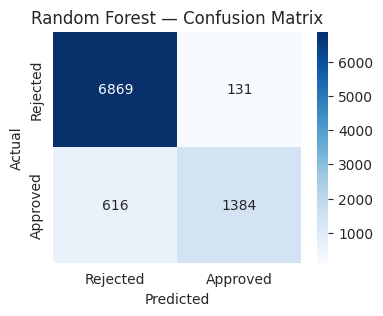

In [118]:
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]
results_summary.append(evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf))

### 6.4 MLP (calibrated)

=== MLP (calibrated) ===
Accuracy:  0.9139
Precision: 0.8486
Recall:    0.7455
F1 Score:  0.7937
ROC-AUC:   0.9649

              precision    recall  f1-score   support

    Rejected       0.93      0.96      0.95      7000
    Approved       0.85      0.75      0.79      2000

    accuracy                           0.91      9000
   macro avg       0.89      0.85      0.87      9000
weighted avg       0.91      0.91      0.91      9000



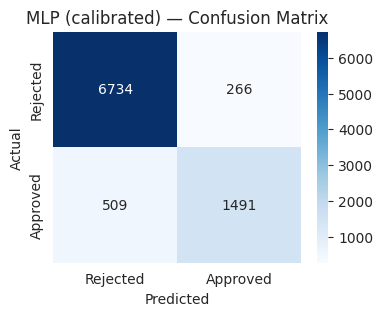

In [119]:
mlp.eval()
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
with torch.no_grad():
    y_proba_mlp = mlp.predict_proba(X_test_t, apply_temperature=True).numpy()
y_pred_mlp = (y_proba_mlp >= 0.5).astype(int)
results_summary.append(evaluate_model("MLP (calibrated)", y_test, y_pred_mlp, y_proba_mlp))

## 7. Soft-Voting Ensemble

Equal-weight average of all 4 models' probabilities — deliberately NOT weighted
by accuracy/AUC, since that would let the MLP's raw confidence dominate the
average purely from being more extreme rather than more correct. Temperature
scaling (above) is what makes equal-weight voting fair.

=== Ensemble (equal-weight soft voting) ===
Accuracy:  0.9194
Precision: 0.8829
Recall:    0.7350
F1 Score:  0.8022
ROC-AUC:   0.9678

              precision    recall  f1-score   support

    Rejected       0.93      0.97      0.95      7000
    Approved       0.88      0.73      0.80      2000

    accuracy                           0.92      9000
   macro avg       0.91      0.85      0.88      9000
weighted avg       0.92      0.92      0.92      9000



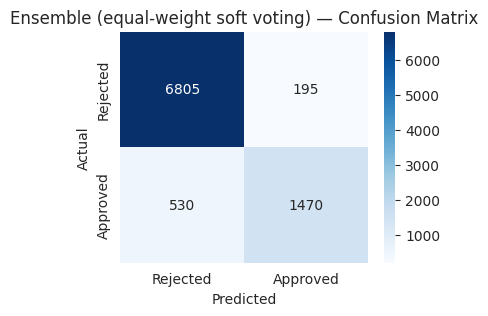

In [120]:
ensemble_proba = np.mean([y_proba_lr, y_proba_dt, y_proba_rf, y_proba_mlp], axis=0)
ensemble_pred = (ensemble_proba >= 0.5).astype(int)

results_summary.append(evaluate_model("Ensemble (equal-weight soft voting)", y_test, ensemble_pred, ensemble_proba))

### ROC Curve Comparison — All Models + Ensemble

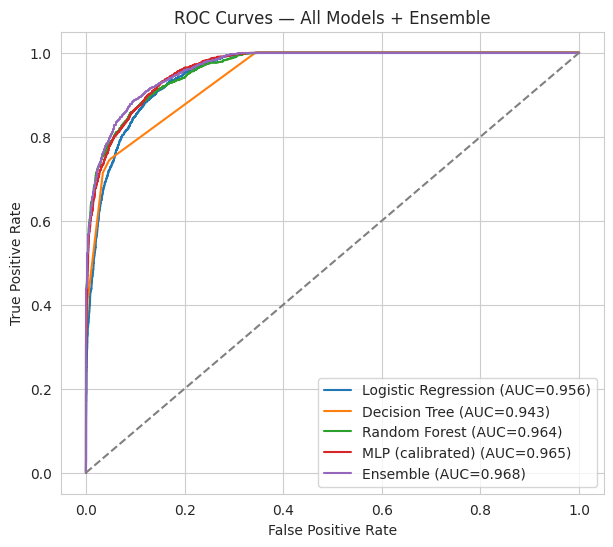

In [121]:
plt.figure(figsize=(7,6))
for name, proba in [
    ("Logistic Regression", y_proba_lr),
    ("Decision Tree", y_proba_dt),
    ("Random Forest", y_proba_rf),
    ("MLP (calibrated)", y_proba_mlp),
    ("Ensemble", ensemble_proba),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models + Ensemble')
plt.legend()
plt.show()

### Summary Comparison Table

In [122]:
results_df = pd.DataFrame(results_summary)
results_df = results_df.sort_values(by='f1', ascending=False).reset_index(drop=True)
results_df

,name,accuracy,precision,recall,f1,auc
0,Ensemble (equal-weight soft voting),0.919444,0.882883,0.7350,0.802183,0.967775
1,MLP (calibrated),0.913889,0.848606,0.7455,0.793718,0.964907
2,Random Forest,0.917000,0.913531,0.6920,0.787482,0.964003
3,Decision Tree,0.909778,0.856115,0.7140,0.778626,0.942987
4,Logistic Regression,0.899778,0.789557,0.7485,0.768480,0.956242


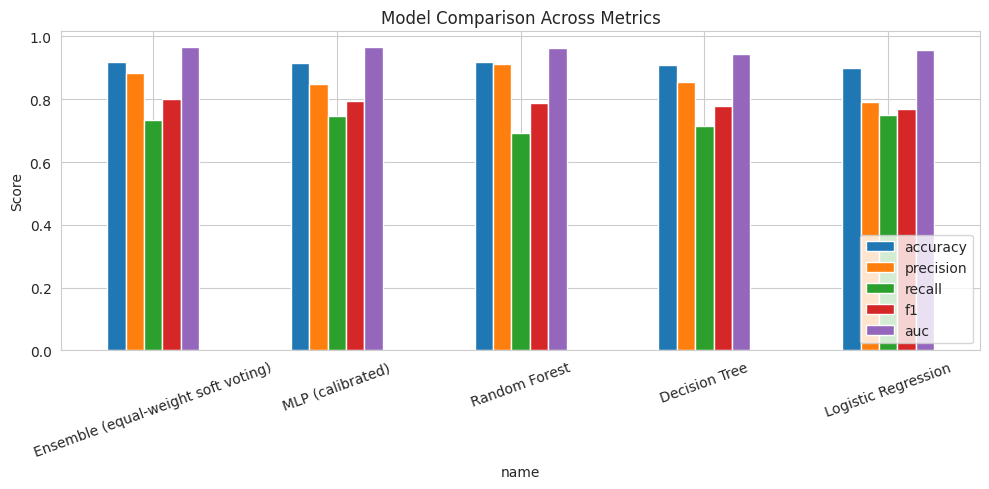

In [123]:
results_df.set_index('name')[['accuracy','precision','recall','f1','auc']].plot(
    kind='bar', figsize=(10,5)
)
plt.title('Model Comparison Across Metrics')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 8. Save Pipeline Artifacts

All trained models, the scaler, feature column order, monotonic mask, and the
results summary are saved to `models_saved/` — these are everything the
Streamlit app needs to load for inference, independent of this notebook.

In [124]:
results_df.to_csv("models_saved/results_summary.csv", index=False)

print("Saved files in models_saved/:")
for f in sorted(os.listdir("models_saved")):
    print(" -", f)

Saved files in models_saved/:
 - decision_tree.joblib
 - feature_columns.joblib
 - logistic_regression.joblib
 - mlp.pt
 - monotonic_mask.joblib
 - random_forest.joblib
 - results_summary.csv
 - scaler.joblib


---
**Pipeline complete.** All 4 models are trained, the MLP is calibrated via temperature
scaling, the monotonicity constraint is verified, and every model (plus the ensemble)
has been evaluated. All artifacts needed for the Streamlit app are saved in `models_saved/`.